In [1]:
%pip install numpy
%pip install pandas
import numpy as np
import pandas as pd
import os

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
base = os.getcwd()
print(base)


c:\Users\priya\OneDrive\Desktop\SmsSpam


In [3]:
df = pd.read_csv("spam.csv", encoding='cp1252')

In [4]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
1677,ham,Lol where do u come up with these ideas?,NaN,NaN,NaN
503,ham,Lolnice. I went from a fish to ..water.?,NaN,NaN,NaN
513,ham,No..jst change tat only..,NaN,NaN,NaN
5198,ham,She.s fine. I have had difficulties with her p...,NaN,NaN,NaN
2381,ham,Best line said in Love: . \I will wait till th...,NaN,NaN,NaN


In [5]:
df.shape

(5572, 5)

In [6]:
#data cleaning
#eda
# text preprovessing 
#model building 
#evaluation
#improvemnt
#website
#deploy

### DATA CLEANING


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [8]:
# drop last three col
df = df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'])

In [9]:
#renaming columns 
df = df.rename(columns={'v1' : 'target', 'v2': 'text'})
df.sample(5)

,target,text
2682,ham,I got a call from a landline number. . . I am ...
82,ham,Ok i am on the way to home hi hi
557,ham,I know that my friend already told that.
4187,ham,Mm umma ask vava also to come tell him can pla...
2911,ham,You didn't have to tell me that...now i'm thin...


In [10]:
#label encoding
%pip install scikit-learn 
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [11]:
df['target'] = encoder.fit_transform(df['target'])
df.sample(5)

,target,text
945,0,I cant wait to see you! How were the photos we...
572,0,Can you open the door?
1716,0,Sorry about earlier. Putting out fires.Are you...
1029,0,"Its good, we'll find a way"
4858,0,"Hey, a guy I know is breathing down my neck to..."


In [12]:
#missing values 
df.isnull().sum()

target    0
text      0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(403)

In [14]:
df = df.drop_duplicates(keep='first')

In [15]:
df.shape

(5169, 2)

### EDA

In [16]:
# kinta percent spam hai aur kitna ham 
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


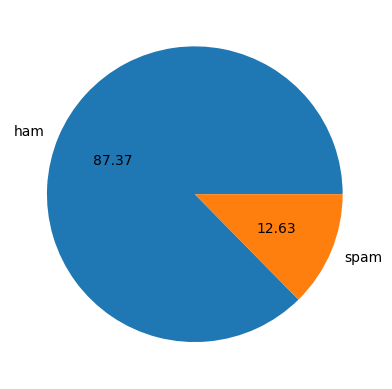

In [17]:
%pip install matplotlib
import matplotlib.pyplot as plt 
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [18]:
#DATA is imbalanced  beacuse of low spam and 

In [19]:
#kitne alaphabets , kitne char , words ,sentensce
%pip install nltk


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\priya\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [21]:
#kitne len hai vo text ki 
df['number_of_characters'] = df['text'].apply(len) 

In [22]:
df.head()

,target,text,number_of_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [23]:
#no of words 
df['number_of_words']=(df['text'].apply(lambda x: len(nltk.word_tokenize(x)) ))

In [24]:
df.head()

,target,text,number_of_characters,number_of_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [25]:
#number of sentences 
df['number_of_sentences'] = df['text'].apply(lambda x : len(nltk.sent_tokenize(x)))

In [26]:
df.head()

,target,text,number_of_characters,number_of_words,number_of_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [27]:
df.describe()

,target,number_of_characters,number_of_words,number_of_sentences
count,5169.000000,5169.000000,5169.000000,5169.000000
mean,0.126330,78.977945,18.455794,1.965564
std,0.332253,58.236293,13.324758,1.448541
min,0.000000,2.000000,1.000000,1.000000
25%,0.000000,36.000000,9.000000,1.000000
50%,0.000000,60.000000,15.000000,1.000000
75%,0.000000,117.000000,26.000000,2.000000
max,1.000000,910.000000,220.000000,38.000000


In [28]:
df[df['target']==0].describe()

,target,number_of_characters,number_of_words,number_of_sentences
count,4516.0,4516.000000,4516.000000,4516.000000
mean,0.0,70.459256,17.123782,1.820195
std,0.0,56.358207,13.493970,1.383657
min,0.0,2.000000,1.000000,1.000000
25%,0.0,34.000000,8.000000,1.000000
50%,0.0,52.000000,13.000000,1.000000
75%,0.0,90.000000,22.000000,2.000000
max,0.0,910.000000,220.000000,38.000000


In [29]:
df[df['target']==1].describe()

,target,number_of_characters,number_of_words,number_of_sentences
count,653.0,653.000000,653.000000,653.000000
mean,1.0,137.891271,27.667688,2.970904
std,0.0,30.137753,7.008418,1.488425
min,1.0,13.000000,2.000000,1.000000
25%,1.0,132.000000,25.000000,2.000000
50%,1.0,149.000000,29.000000,3.000000
75%,1.0,157.000000,32.000000,4.000000
max,1.0,224.000000,46.000000,9.000000


In [30]:
# we cann see that spam messages are longer 
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import seaborn as sns

<Axes: xlabel='number_of_characters', ylabel='Count'>

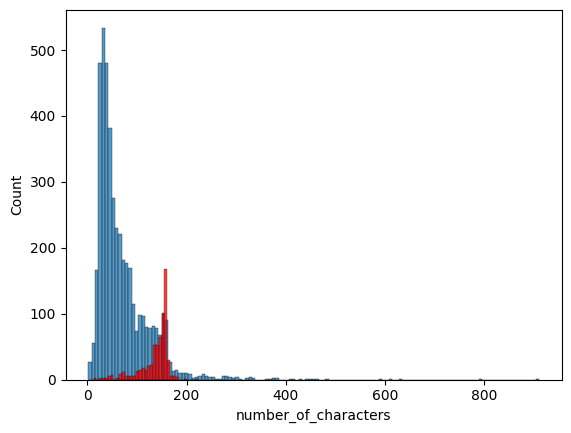

In [32]:
sns.histplot(df[df['target']==0]['number_of_characters'])
sns.histplot(df[df['target']==1]['number_of_characters'],color='red')

<Axes: xlabel='number_of_words', ylabel='Count'>

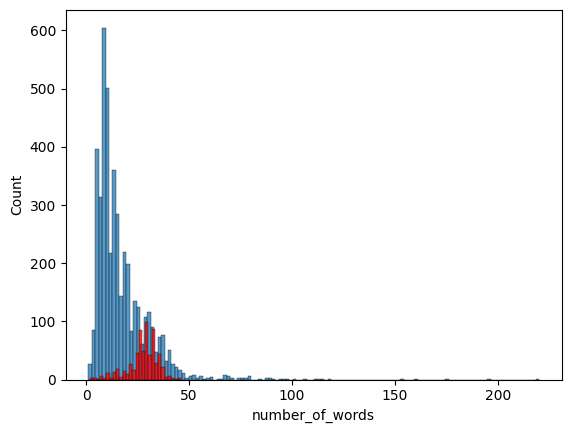

In [33]:
sns.histplot(df[df['target']==0]['number_of_words'])
sns.histplot(df[df['target']==1]['number_of_words'],color='red')

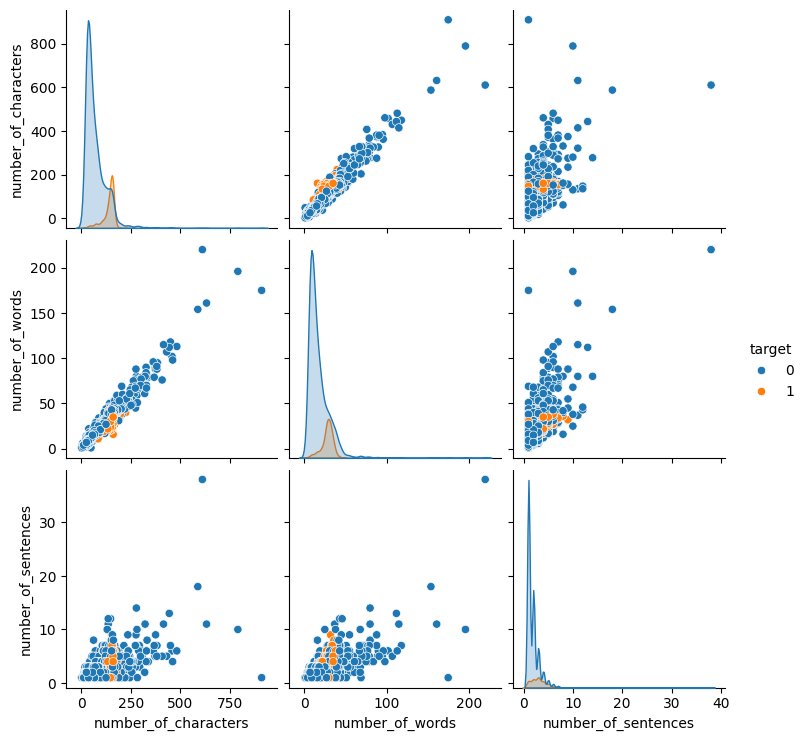

In [34]:
#co relation btw columns
sns.pairplot(df,hue='target')

<Axes: >

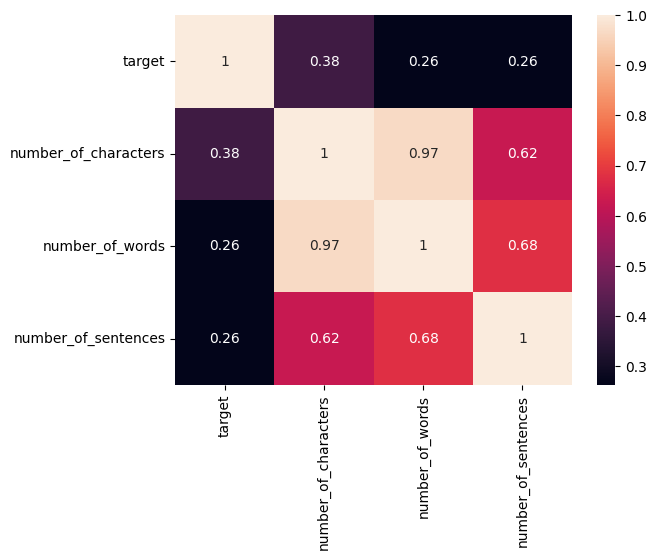

In [35]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

# DATA Preprocessing 


In [36]:
#lower case 
#tokenization
#removing special characters
#removing stop words and punctuations
#stemming 

from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
import string

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\priya\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [37]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    y  = []
    
    for i in text :
        if i.isalnum():
            y.append(i)

    text = y[:]  # we need to clone if we to text = y , than new is not made so if we clear y , than text is also cleared  
    y.clear()

    for i in text :
        if i not in stopwords.words('english') and i not in string.punctuation :
            y.append(ps.stem(i))
    return y

In [38]:
transform_text('hi i am how are greating , inform delhi  you , ilv!! !!,, m')

['hi', 'great', 'inform', 'delhi', 'ilv']

In [39]:
df['transformed_text'] =df['text'].apply(transform_text)

In [40]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
from wordcloud import WordCloud
wc = WordCloud()

In [42]:
# Create a temporary series to avoid SettingWithCopyWarning if it's a slice
spam_text = df[df['target']==1]['transformed_text'].astype(str)

# Now apply str.cat
spam_wc = wc.generate(spam_text.str.cat(sep=" "))


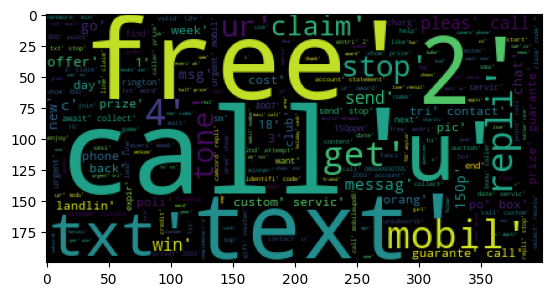

In [43]:
plt.imshow(spam_wc)

In [44]:
df.head()

,target,text,number_of_characters,number_of_words,number_of_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,"[go, jurong, point, crazi, avail, bugi, n, gre..."
1,0,Ok lar... Joking wif u oni...,29,8,2,"[ok, lar, joke, wif, u, oni]"
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,"[free, entri, 2, wkli, comp, win, fa, cup, fin..."
3,0,U dun say so early hor... U c already then say...,49,13,1,"[u, dun, say, earli, hor, u, c, alreadi, say]"
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,"[nah, think, goe, usf, live, around, though]"


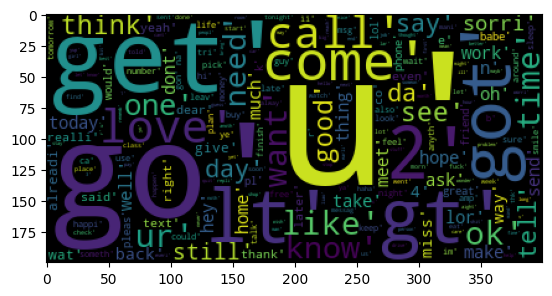

In [45]:
ham_text = df[df['target']==0]['transformed_text'].astype(str)

# Now apply str.cat
ham_wc = wc.generate(ham_text.str.cat(sep=" "))
plt.imshow(ham_wc)

In [46]:
# top 30 words of ham and spam 
spam_corpus =[]
for msg in df[df['target']==1]['transformed_text'].tolist():
    for word in msg:
        spam_corpus.append(word) 

In [47]:
len(spam_corpus)

9939

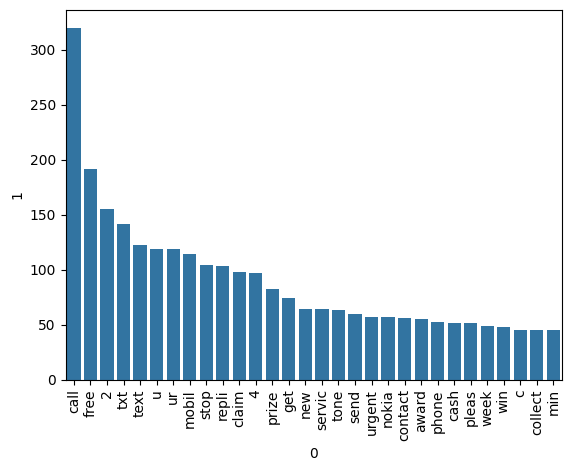

In [48]:
from collections import Counter 

top30 = pd.DataFrame(Counter(spam_corpus).most_common(30))
sns.barplot(x= top30[0],y=top30[1])
plt.xticks(rotation='vertical')
plt.show()


In [49]:
# top 30 words of ham and spam 
ham_corpus =[]
for msg in df[df['target']==0]['transformed_text'].tolist():
    for word in msg:
        ham_corpus.append(word) 

In [50]:
len(ham_corpus)

35404

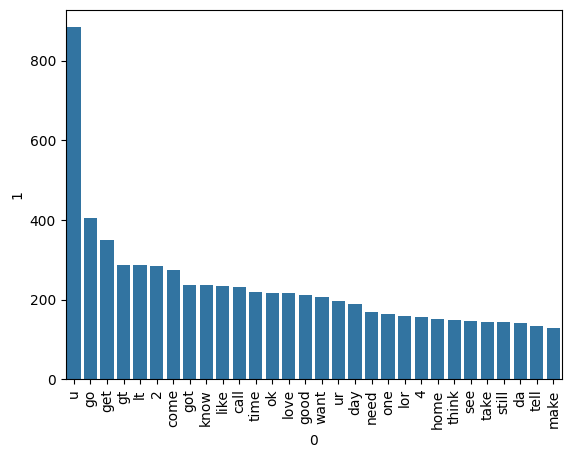

In [51]:
top30ham = pd.DataFrame(Counter(ham_corpus).most_common(30))
sns.barplot(x= top30ham[0],y=top30ham[1])
plt.xticks(rotation='vertical')
plt.show()

# MODEL TRAINING


In [52]:
print(df['text'])

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                Will Ì_ b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: text, Length: 5169, dtype: str


In [53]:
#text to vector
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()

X= cv.fit_transform(df['text']).toarray()
# print(X)
X.shape

(5169, 8673)

In [55]:
y = df['target'].values
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [78]:
from sklearn.model_selection import train_test_split
X_train ,X_test ,y_train ,y_test = train_test_split(X,y,test_size = 0.2 , random_state = 2)


In [79]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB

from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [80]:
gnb = GaussianNB()
mnb  = MultinomialNB()
bnb = BernoulliNB()

In [84]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.9148936170212766
[[824  72]
 [ 16 122]]
0.6288659793814433


In [83]:
mnb.fit(X_train,y_train)
y_pred2 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9148936170212766
[[824  72]
 [ 16 122]]
0.6288659793814433


In [82]:
bnb.fit(X_train,y_train)
y_pred3 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9148936170212766
[[824  72]
 [ 16 122]]
0.6288659793814433


In [85]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [98]:

svc = SVC(kernel='sigmoid', gamma=1.0,class_weight='balanced')
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [99]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [100]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [101]:

train_classifier(svc,X_train,y_train,X_test,y_test)

(0.6914893617021277, 0.26370757180156656)

In [102]:

accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)


For  SVC
Accuracy -  0.6914893617021277
Precision -  0.26370757180156656
For  KN
Accuracy -  0.9119922630560928
Precision -  1.0
For  NB
Accuracy -  0.97678916827853
Precision -  0.88
For  DT
Accuracy -  0.9410058027079303
Precision -  0.8532110091743119


c:\Users\priya\OneDrive\Desktop\SmsSpam\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\priya\OneDrive\Desktop\SmsSpam\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


For  LR
Accuracy -  0.9806576402321083
Precision -  0.9758064516129032
For  RF
Accuracy -  0.9680851063829787
Precision -  1.0
For  AdaBoost
Accuracy -  0.9410058027079303
Precision -  0.8888888888888888
For  BgC
Accuracy -  0.965183752417795
Precision -  0.8923076923076924
For  ETC
Accuracy -  0.9787234042553191
Precision -  1.0
For  GBDT
Accuracy -  0.9468085106382979
Precision -  0.9278350515463918
For  xgb
Accuracy -  0.9787234042553191
Precision -  0.9603174603174603


In [91]:

performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [92]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.911992,1.000000
8,ETC,0.978723,1.000000
5,RF,0.968085,1.000000
4,LR,0.980658,0.975806
10,xgb,0.978723,0.960317
9,GBDT,0.946809,0.927835
7,BgC,0.965184,0.892308
6,AdaBoost,0.941006,0.888889
2,NB,0.976789,0.880000
3,DT,0.941973,0.854545


we can see that etc , kn , rf, are better performing with precison , ,,, lr is performing best,,, let us try taking ensemble because precsion is important , 

NameError: name 'models' is not defined

NotFittedError: This VotingClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.